In [1]:
import rebound
import reboundx
import astropy.constants as constants
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from multiprocess import Pool
import celmech
import warnings
from joblib import Parallel, delayed
from celmech.miscellaneous import frequency_modified_fourier_transform as fmftc
import matplotlib.pyplot as plt
import scipy.fftpack as fftpack
import seaborn as sns
import scipy.stats as stats
import os
import glob
from pathlib import Path

Change: 2025-03-13 20:47:33.254904454 +0000 
Birth: 2025-03-11 23:24:32.598419282 +0000

In [1885]:
sa = rebound.Simulationarchive("runs/run_1.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 1003
Time of first and last snapshot: 0.0, -3500000000.0


In [1886]:
print(abs(100*sa.tmax/(3.5e9)),"%")

100.0 %


In [1887]:
sa = rebound.Simulationarchive("test_030325.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 100001
Time of first and last snapshot: 0.0, -3500000000.0


In [1888]:
print(abs(100*sa.tmax/(3.5e9)),"%")

100.0 %


In [1889]:
sa = rebound.Simulationarchive("test_030325.bin")

es = np.zeros(len(sa))
pomegas = np.zeros(len(sa))
Es = np.zeros(len(sa))
Eerr = np.zeros(len(sa))
times = np.zeros(len(sa))
L = np.zeros(len(sa))
Lerr = np.zeros(len(sa))

for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    earth = qps['earth']
    rebx = reboundx.Extras(sim)

    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    cf = rebx.load_force("quadrupole")
    rebx.add_force(cf)
    earth_m = earth.m/1.012
    f = 0.8525
    mu_eff = f*(1*0.012*(earth_m)**2)/(1.012*earth_m)
    R = 0.0025696

    earth.params["Rcentral"] = R
    earth.params["mu_effcentral"] = mu_eff

    sim.integrator_synchronize()

    if i==0:
        E0 = sim.energy()+ rebx.quad_force_potential() + rebx.gr_potential_potential(gr) + rebx.gravitational_harmonics_potential()
        Lx0, Ly0, Lz0 = sim.angular_momentum()
    
    es[i] = earth.e
    pomegas[i]=earth.pomega
    times[i] = sim.t
    
    E = sim.energy() + rebx.quad_force_potential() + rebx.gr_potential_potential(gr) + rebx.gravitational_harmonics_potential()
    Es[i] = E
    Eerr[i] = np.abs((E-E0)/E0)

    Lx, Ly, Lz = sim.angular_momentum()
    L[i] = Lz
    Lerr[i] = np.abs((Lz-Lz0)/(Lz0+Lx0+Ly0))

In [1944]:
sa = rebound.Simulationarchive("runs/run_1.bin")

R_e = (constants.R_earth.to(u.au)).value
ratio = R / R_e

Nout = len(sa)

obl = np.zeros(Nout)
esinw = np.zeros(Nout)
e = np.zeros(Nout)
p = np.zeros(Nout)
pom = np.zeros(Nout)
incs = np.zeros(Nout)
els = np.zeros(Nout)
times2 = np.zeros(Nout)

n = 8
a = np.zeros((Nout,n))
z = np.zeros((Nout, n), dtype=complex)
ζ = np.zeros((Nout, n), dtype=complex)

for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    earth = qps['earth']
    mass[i] = qps[0].m
    rebx = reboundx.Extras(sim)

    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    cf = rebx.load_force("quadrupole")
    rebx.add_force(cf)
    earth_m = earth.m/1.012
    f = 0.8525
    mu_eff = f*(1*0.012*(earth_m)**2)/(1.012*earth_m)

    time = sim.t
    times2[i]=time
    r = (ratio-((5.14/ 1.e9)*(abs(time))))*R_e
    earth.params["Rcentral"] = r
    Rchive [i] = earth.params["Rcentral"]
    earth.params["mu_effcentral"] = mu_eff

    gh = rebx.load_force("gravitational_harmonics")
    rebx.add_force(gh)
    J2 = 2.25*1e-7
    sim.particles['sun'].params["J2"] = J2
    inc_sun = np.radians(7.155) # rad
    Omega_sun = np.radians(75.594) # rad
    R_eq_sun = (constants.R_sun.to(u.au)).value
    spin_axis_vector = [np.sin(inc_sun) * np.sin(Omega_sun), -np.sin(inc_sun) * np.cos(Omega_sun), np.cos(inc_sun)]
    sim.particles['sun'].params["Omega"] = spin_axis_vector
    sim.particles['sun'].params["R_eq"] = R_eq_sun

    sim.integrator_synchronize()
    orbits = sim.orbits()

    if i==0:
        E0 = sim.energy()+ rebx.quad_force_potential() + rebx.gr_potential_potential(gr) + rebx.gravitational_harmonics_potential()
        Lx0, Ly0, Lz0 = sim.angular_momentum()
    
    for j in range(n):
        a[i,j] = orbits[j].a
        z[i,j] = orbits[j].e * np.exp(1j*orbits[j].pomega)
        ζ[i,j] = np.sin(orbits[j].inc/2.) * np.exp(1j*orbits[j].Omega)

    # Omega = np.array(qps['earth'].params['Omega'])
    # h = np.array(qps['earth'].hvec)
    # obl[i] = np.arccos(np.dot(Omega, h)/np.linalg.norm(Omega)/np.linalg.norm(h))*180/np.pi
    esinw[i] = qps['earth'].e*np.sin(qps['earth'].pomega)
    e[i] = qps['earth'].e
    p[i] = (1 - (qps['earth'].e)**2) / (1 + (qps['earth'].e * np.cos(qps['earth'].f)))
    pom[i] = np.sin(qps['earth'].pomega)
    incs[i] = qps['earth'].inc
    els[i] = qps['earth'].l
    
    E = sim.energy() + rebx.quad_force_potential() + rebx.gr_potential_potential(gr) + rebx.gravitational_harmonics_potential()
    Eerr2[i] = np.abs((E-E0)/E0)

    Lx, Ly, Lz = sim.angular_momentum()
    Lerr2[i] = np.abs((Lz-Lz0)/(Lz0+Lx0+Ly0))

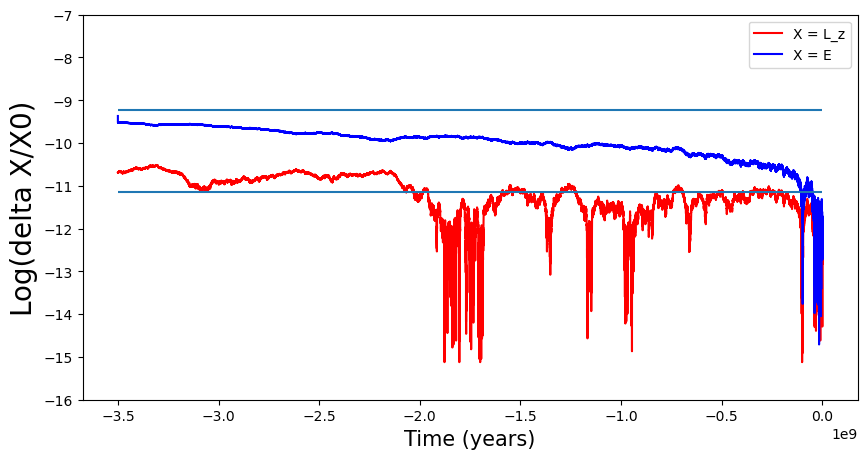

In [1912]:
plt.figure(figsize=[10,5])
plt.plot(times[2::], np.log10(abs(Lerr[2::])), '-', label='X = L_z', color='red')
plt.plot(times[2::], np.log10(abs(Eerr[2::])), '-', label='X = E', color='blue')
plt.hlines(np.log10(6*1e-10), np.min(times),np.max(times))
plt.hlines(np.log10(7*1e-12), np.min(times),np.max(times))
plt.ylim(-16,-7)
# plt.xlim(np.min(times3),np.max(times3))
plt.ylabel("Log(delta X/X0)", fontsize=20)
plt.xlabel("Time (years)", fontsize=15)
plt.legend()
plt.legend()
plt.show()

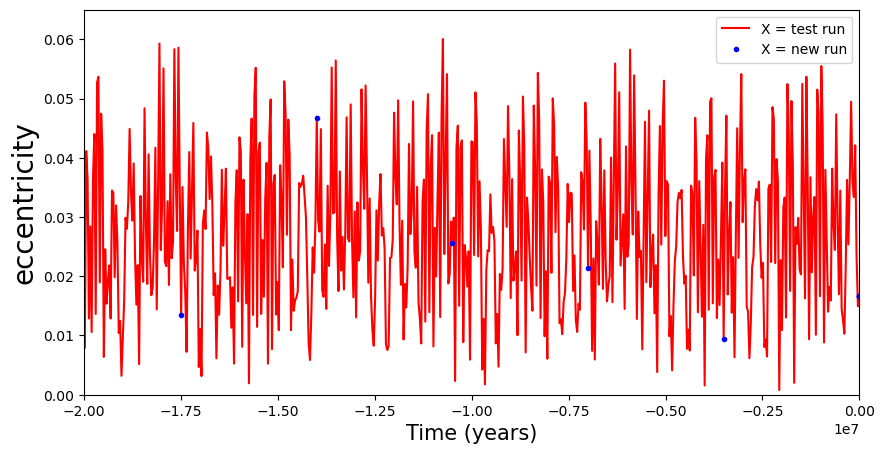

In [1913]:
plt.figure(figsize=[10,5])
plt.plot(times, es, '-', label='X = test run', color='red')
plt.plot(times2, es2, '.', label='X = new run', color='blue')
# plt.xlim(min(times2),0)
plt.xlim(-20e6,-0e6)
# plt.xlim(-1190e6,-1170e6)
plt.ylim(0,0.065)
plt.ylabel("eccentricity", fontsize=20)
plt.xlabel("Time (years)", fontsize=15)
plt.legend()
plt.legend()
plt.show()

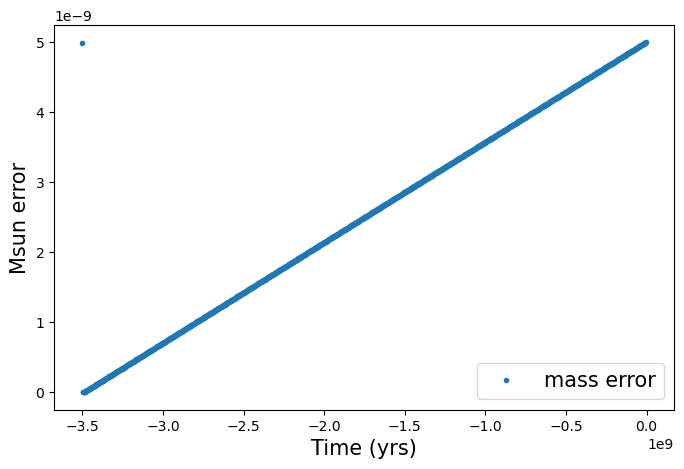

In [1914]:
M0 = mass[0]
rate = -(7.e14)
pred2 = M0*(1+(times2/rate))
pred = M0*np.exp(times2 / rate)
error = abs(mass - pred2)/pred2
fig = plt.figure(figsize=(8,5))
ax = plt.subplot(111)
ax.plot(times2[3::],abs(error[3::]), '.',label='mass error')

# ax.plot(times2,mass, '.',label='simulation')
# ax.plot(times2,pred, label='pred. exponential')
# ax.plot(times2,pred2, label='pred. linear')
ax.set_xlabel("Time (yrs)", fontsize=15)
ax.set_ylabel("Msun error", fontsize=15)
ax.legend(fontsize=15);

In [1915]:
def radii(x):
    y = np.zeros(len(x))
    for i, time in enumerate(x):
        # y[i] = (ratio-((5.14/ 1.e9)*(abs(time))))*R_e
        y[i] = ratio*R_e*(1-(2.199229*1e-13/(ratio*R_e))*(abs(time)))
    return y

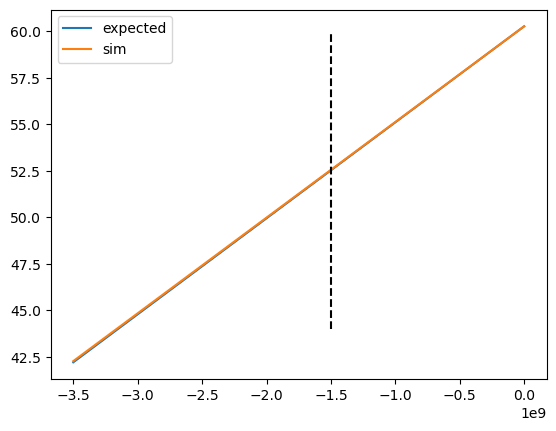

In [1916]:
plt.plot(times2, radii(times2)/R_e, label='expected')
plt.plot(times2, Rchive/R_e, label='sim')
plt.vlines(-1.5e9,44,60, 'black','--')
# plt.xlim(max(times),min(times))
plt.legend()
plt.show()

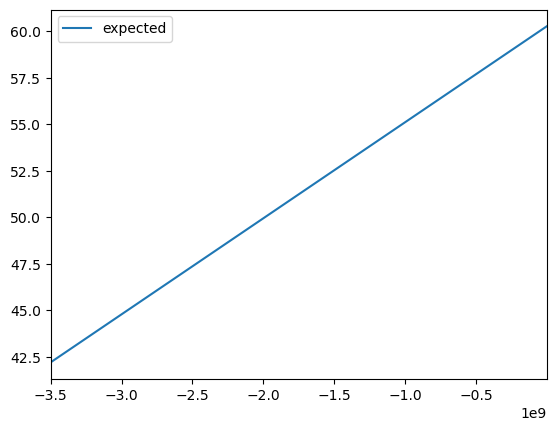

In [1917]:
ztime = np.arange(-3.5e9,0,step=1e5)
plt.plot(ztime, radii(ztime)/R_e, label='expected')
plt.xlim(min(ztime),max(ztime))
plt.legend()
plt.show()